In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm
from scipy.stats import chi2_contingency

In [48]:
df=pd.read_csv('cleaned_data.csv')
df

,model,price,rating,os,sim_type,network_type,VoLTE,NFC,ir_blaster,chipset,...,resolution,refresh_rate_hz,display_type,rear_camera_mp_list,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_type,memory_card_max_gb
0,oneplus 11 5g,54999,89,Android v13,Dual,5g,True,True,False,Snapdragon 8 Gen2,...,1440x3216,120.0,Punch Hole,"[50, 48, 32]",3,50.0,16.0,1,NaN,NaN
1,oneplus nord ce 2 lite 5g,19989,81,Android v12,Dual,5g,True,False,False,Snapdragon 695,...,1080x2412,120.0,Punch Hole,"[64, 2, 2]",3,64.0,16.0,1,Hybrid,1024.0
2,samsung galaxy a14 5g,16499,75,Android v13,Dual,5g,True,False,False,Exynos 1330,...,1080x2408,90.0,Water Drop Notch,"[50, 2, 2]",3,50.0,13.0,1,Dedicated,1024.0
3,motorola moto g62 5g,14999,81,Android v12,Dual,5g,True,False,False,Snapdragon 695,...,1080x2400,120.0,Punch Hole,"[50, 8, 2]",3,50.0,16.0,1,Hybrid,1024.0
4,realme 10 pro plus,24999,82,Android v13,Dual,5g,True,False,False,Dimensity 1080,...,1080x2412,120.0,Punch Hole,"[108, 8, 2]",3,108.0,16.0,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
963,motorola moto edge s30 pro,34990,83,Android v12,Dual,5g,True,False,False,Snapdragon 8 Gen1,...,1080x2460,120.0,Punch Hole,"[64, 8, 2]",3,64.0,16.0,1,Dedicated,NaN
964,honor x8 5g,14990,75,Android v11,Dual,5g,True,False,False,Snapdragon 480+,...,720x1600,NaN,Water Drop Notch,"[48, 2]",2,48.0,8.0,1,Dedicated,1024.0
965,poco x4 gt 5g,28990,85,Android v12,Dual,5g,True,True,True,Dimensity 8100,...,1080x2460,144.0,Punch Hole,"[64, 8, 2]",3,64.0,16.0,1,NaN,NaN
966,motorola moto g91 5g,19990,80,Android v12,Dual,5g,True,True,False,Snapdragon 695,...,1080x2400,NaN,Punch Hole,"[108, 8, 2]",3,108.0,32.0,1,Dedicated,1024.0


In [49]:
df.shape

(968, 27)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 968 entries, 0 to 967
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   model                  968 non-null    object 
 1   price                  968 non-null    int64  
 2   rating                 968 non-null    int64  
 3   os                     942 non-null    object 
 4   sim_type               968 non-null    object 
 5   network_type           968 non-null    object 
 6   VoLTE                  968 non-null    bool   
 7   NFC                    968 non-null    bool   
 8   ir_blaster             968 non-null    bool   
 9   chipset                968 non-null    object 
 10  core_type              962 non-null    object 
 11  clock_ghz              927 non-null    float64
 12  ram_gb                 968 non-null    int64  
 13  storage_gb             968 non-null    int64  
 14  battery_mah            957 non-null    float64
 15  fast_c

In [51]:
df.describe()

,price,rating,clock_ghz,ram_gb,storage_gb,battery_mah,fast_charge_w,screen_size_in,refresh_rate_hz,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_max_gb
count,968.000000,968.000000,927.000000,968.000000,968.000000,957.000000,764.00000,967.000000,608.000000,968.000000,952.000000,943.000000,968.0,500.000000
mean,32745.954545,78.540289,2.430237,7.641529,7.641529,4819.935214,46.25877,6.535998,111.656250,2.268595,50.737395,16.714740,1.0,741.136000
std,39707.710721,6.953266,0.464864,23.123619,23.123619,1012.724563,34.30833,0.381498,18.488393,0.905096,33.209502,10.889245,0.0,375.426488
min,2999.000000,60.000000,1.000000,1.000000,1.000000,1500.000000,10.00000,2.400000,90.000000,0.000000,2.000000,2.000000,1.0,32.000000
25%,12999.000000,75.000000,2.050000,4.000000,4.000000,4500.000000,18.00000,6.500000,90.000000,1.000000,48.000000,8.000000,1.0,512.000000
50%,19999.000000,80.000000,2.360000,6.000000,6.000000,5000.000000,33.00000,6.580000,120.000000,3.000000,50.000000,16.000000,1.0,1024.000000
75%,35992.250000,84.000000,2.840000,8.000000,8.000000,5000.000000,66.00000,6.670000,120.000000,3.000000,64.000000,16.000000,1.0,1024.000000
max,650000.000000,89.000000,3.220000,512.000000,512.000000,22000.000000,240.00000,8.030000,240.000000,4.000000,200.000000,60.000000,1.0,2048.000000


In [52]:
# Step 1: split the camera column
split_cols = (
    df['rear_camera_mp_list']
    .str.strip('[]')
    .str.split(',', expand=True)
    .iloc[:, :3]
    .apply(pd.to_numeric, errors='coerce')
)

split_cols.columns = ['Wide_Camera', 'Main_Camera', 'Selfie_Camera']

# Step 2: find position of original column
pos = df.columns.get_loc('rear_camera_mp_list')

# Step 3: insert new columns at correct position
for i, col in enumerate(split_cols.columns):
    df.insert(pos + 1 + i, col, split_cols[col])

df.drop(columns=['rear_camera_mp_list'], inplace=True)

In [53]:
unique=df.nunique(dropna=False).sort_values(ascending=False)
unique

model                    777
price                    376
chipset                  240
battery_mah               89
resolution                85
screen_size_in            82
clock_ghz                 38
os                        36
fast_charge_w             34
rating                    30
front_camera_mp           18
rear_camera_max_mp        18
Wide_Camera               17
Main_Camera               16
Selfie_Camera             13
ram_gb                    10
storage_gb                10
memory_card_max_gb         9
refresh_rate_hz            6
display_type               6
core_type                  5
rear_camera_count          5
memory_card_type           3
network_type               2
ir_blaster                 2
sim_type                   2
VoLTE                      2
NFC                        2
memory_card_supported      1
dtype: int64

In [54]:
y=len(df)
unique1=[c for c in df.columns if df[c].nunique(dropna=False)==y]
unique1

[]

In [55]:
y=0.95*len(df)
unique1=[c for c in df.columns if df[c].nunique(dropna=False)>=y]
unique1

[]

In [56]:
duplicate=df[df.duplicated()]
print(f'Total duplicate:{duplicate.shape[0]}')

Total duplicate:0


In [57]:
df.isna().sum()

model                      0
price                      0
rating                     0
os                        26
sim_type                   0
network_type               0
VoLTE                      0
NFC                        0
ir_blaster                 0
chipset                    0
core_type                  6
clock_ghz                 41
ram_gb                     0
storage_gb                 0
battery_mah               11
fast_charge_w            204
screen_size_in             1
resolution                 1
refresh_rate_hz          360
display_type              85
Wide_Camera               16
Main_Camera              255
Selfie_Camera            451
rear_camera_count          0
rear_camera_max_mp        16
front_camera_mp           25
memory_card_supported      0
memory_card_type         127
memory_card_max_gb       468
dtype: int64

In [58]:
def imputenull(df):
    for col in df.columns:
        if col in df.select_dtypes(include=['float64', 'int64','int32']).columns:
            if df[col].isna().any() and df[col].skew()<3:
                df[col] = df[col].fillna(df[col].mean())
            else:
                df[col] = df[col].fillna(df[col].median())
        else:
            if df[col].isna().any():
                df[col] = df[col].fillna(df[col].mode()[0])
                #data[col] = data[col].fillna(data[col].value_counts().index[0])


imputenull(df)

In [59]:
threshold = 0.75 * len(df)
cols_with_majority_same = [col for col in df.columns if df[col].value_counts(dropna=False).max() >= threshold]
print("Columns with 75%+ same values:")
print(cols_with_majority_same)

Columns with 75%+ same values:
['sim_type', 'VoLTE', 'ir_blaster', 'core_type', 'Selfie_Camera', 'memory_card_supported', 'memory_card_type']


In [60]:
pd.crosstab(df['Selfie_Camera'], df['sim_type'], normalize='index')

sim_type,Dual,Single
Selfie_Camera,,
2.0,0.985366,0.014634
3.0,1.000000,0.000000
5.0,1.000000,0.000000
8.0,0.913043,0.086957
10.0,1.000000,0.000000
12.0,0.958333,0.041667
13.0,1.000000,0.000000
16.0,1.000000,0.000000
32.0,1.000000,0.000000


In [71]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

outliers_summary = {}
for col in numeric_cols:
    outliers = detect_outliers(df, col)
    outliers_summary[col] = len(outliers)

print("Outliers in numeric columns:")
print(outliers_summary)

Outliers in numeric columns:
{'price': 0, 'rating': 0, 'clock_ghz': 0, 'ram_gb': 0, 'storage_gb': 0, 'battery_mah': 0, 'fast_charge_w': 0, 'screen_size_in': 0, 'refresh_rate_hz': 0, 'Wide_Camera': 0, 'Main_Camera': 0, 'Selfie_Camera': 0, 'rear_camera_count': 0, 'rear_camera_max_mp': 0, 'front_camera_mp': 0, 'memory_card_supported': 0, 'memory_card_max_gb': 0}


In [72]:
for i in outliers_summary.keys():
    if outliers_summary[i]>0:
        outliers=detect_outliers(df,i)
        df[i][outliers.index]=np.median(df[i])

In [80]:
for col in df.select_dtypes(include='number').columns:
    print(f'col: {col},skewness: {df[col].skew()}')

col: price,skewness: -0.11936656599580664
col: rating,skewness: -0.7350451709257861
col: clock_ghz,skewness: 0.15796724064959508
col: ram_gb,skewness: 0.4166924690688844
col: storage_gb,skewness: 0.4166924690688844
col: battery_mah,skewness: -0.4711227216679474
col: fast_charge_w,skewness: 0.15588446526120833
col: screen_size_in,skewness: 0.13040795163406324
col: refresh_rate_hz,skewness: 0.6100084189451191
col: Main_Camera,skewness: -0.1738390013505149
col: rear_camera_count,skewness: -0.5717257961238903
col: front_camera_mp,skewness: -0.5104702419293292
col: memory_card_max_gb,skewness: 0.2008586942837787


In [74]:
df=df.drop(columns=['memory_card_supported','rear_camera_max_mp','Selfie_Camera','Wide_Camera'])
df

,model,price,rating,os,sim_type,network_type,VoLTE,NFC,ir_blaster,chipset,...,fast_charge_w,screen_size_in,resolution,refresh_rate_hz,display_type,Main_Camera,rear_camera_count,front_camera_mp,memory_card_type,memory_card_max_gb
0,oneplus 11 5g,19999,89,Android v13,Dual,5g,True,True,False,Snapdragon 8 Gen2,...,44.12500,6.70,1440x3216,120.00000,Punch Hole,8.0,3,16.0,Dedicated,741.136
1,oneplus nord ce 2 lite 5g,19989,81,Android v12,Dual,5g,True,False,False,Snapdragon 695,...,33.00000,6.59,1080x2412,120.00000,Punch Hole,2.0,3,16.0,Hybrid,1024.000
2,samsung galaxy a14 5g,16499,75,Android v13,Dual,5g,True,False,False,Exynos 1330,...,15.00000,6.60,1080x2408,111.65625,Water Drop Notch,2.0,3,13.0,Dedicated,1024.000
3,motorola moto g62 5g,14999,81,Android v12,Dual,5g,True,False,False,Snapdragon 695,...,46.25877,6.55,1080x2400,120.00000,Punch Hole,8.0,3,16.0,Hybrid,1024.000
4,realme 10 pro plus,24999,82,Android v13,Dual,5g,True,False,False,Dimensity 1080,...,67.00000,6.70,1080x2412,120.00000,Punch Hole,8.0,3,16.0,Dedicated,741.136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
963,motorola moto edge s30 pro,19999,83,Android v12,Dual,5g,True,False,False,Snapdragon 8 Gen1,...,68.20000,6.67,1080x2460,120.00000,Punch Hole,8.0,3,16.0,Dedicated,741.136
964,honor x8 5g,14990,75,Android v11,Dual,5g,True,False,False,Snapdragon 480+,...,22.50000,6.50,720x1600,111.65625,Water Drop Notch,2.0,2,8.0,Dedicated,1024.000
965,poco x4 gt 5g,28990,85,Android v12,Dual,5g,True,True,True,Dimensity 8100,...,67.00000,6.60,1080x2460,111.65625,Punch Hole,8.0,3,16.0,Dedicated,741.136
966,motorola moto g91 5g,19990,80,Android v12,Dual,5g,True,True,False,Snapdragon 695,...,46.25877,6.80,1080x2400,111.65625,Punch Hole,8.0,3,16.0,Dedicated,1024.000


In [79]:
df['battery_mah'] = df['battery_mah']**2

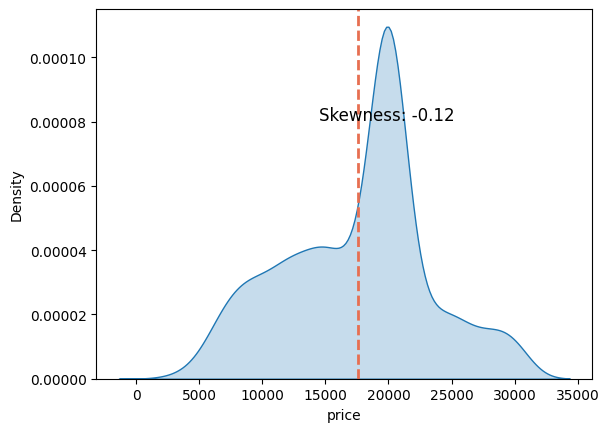

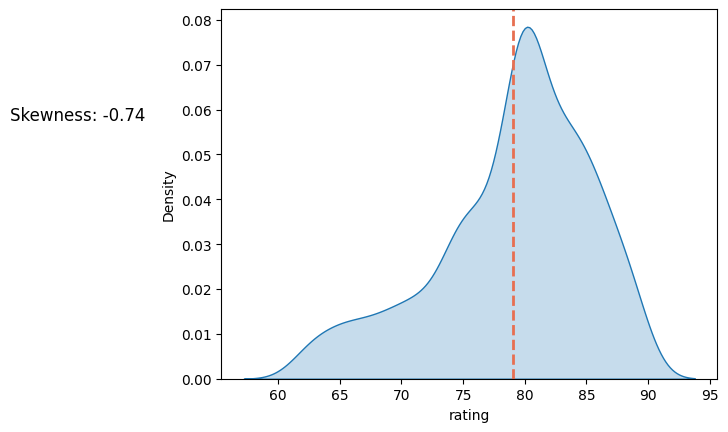

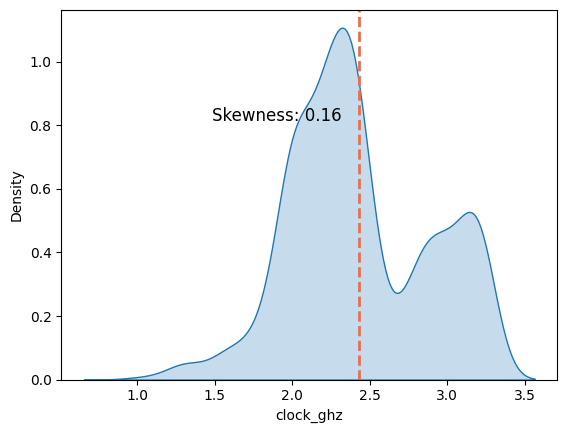

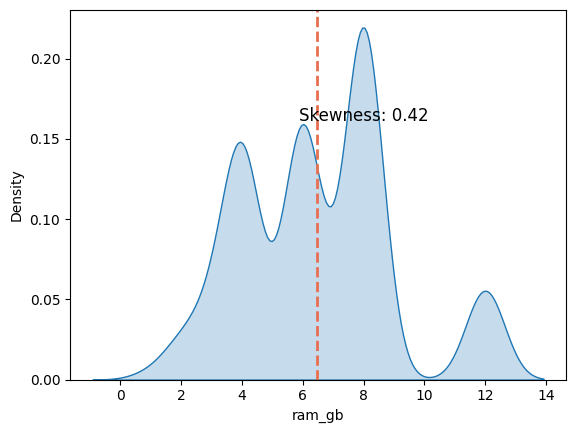

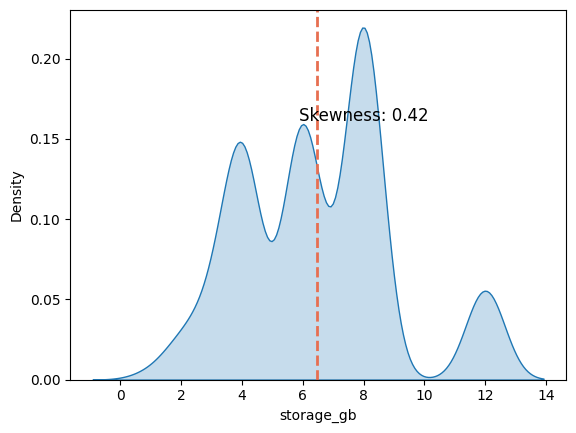

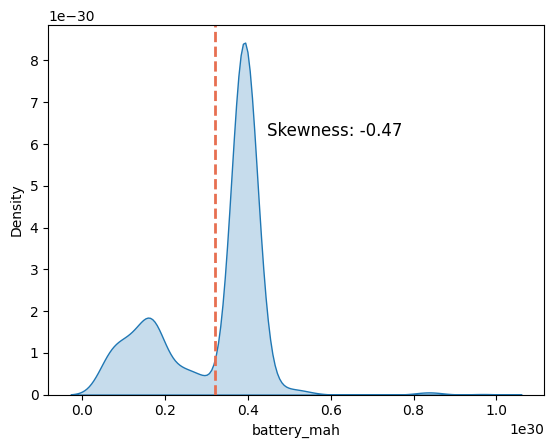

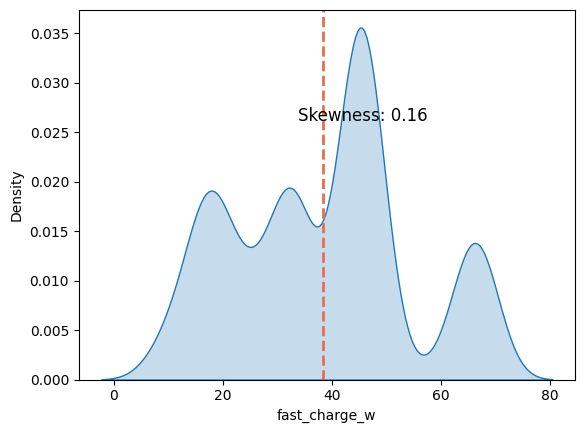

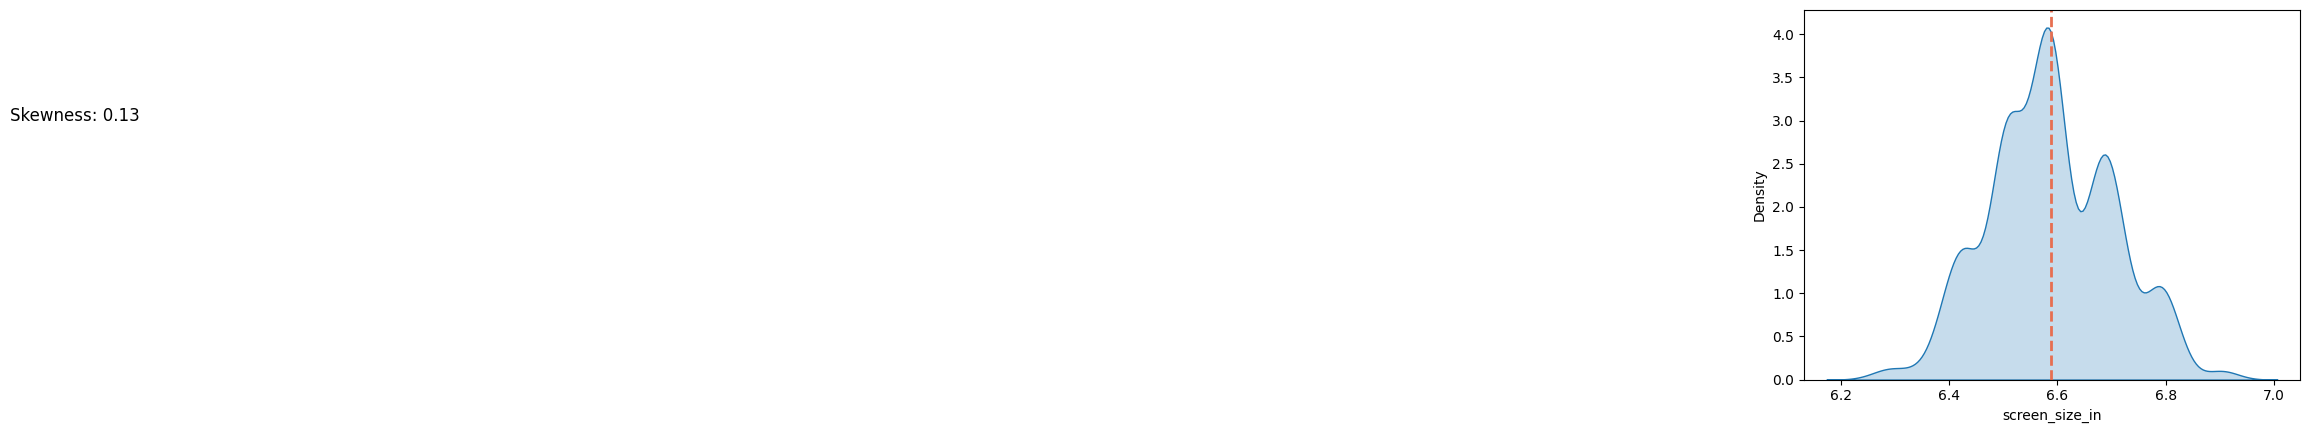

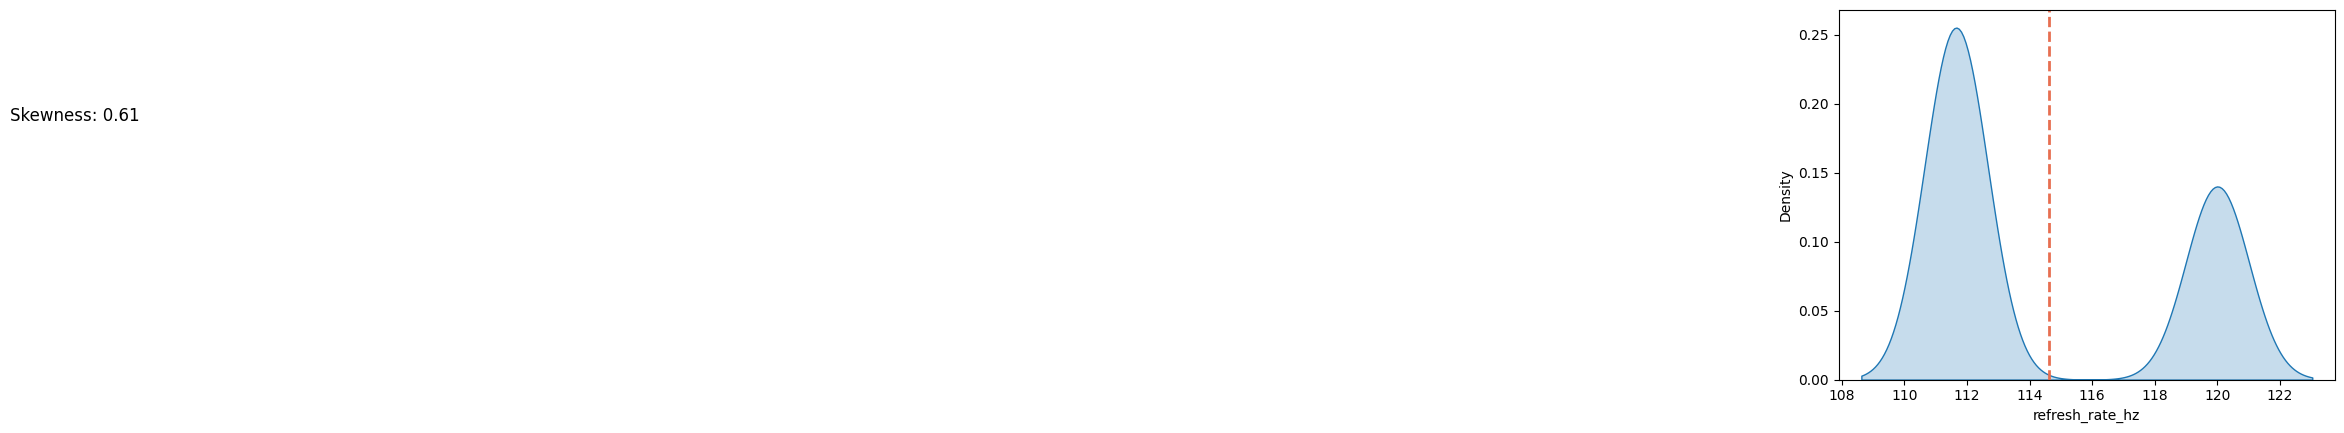

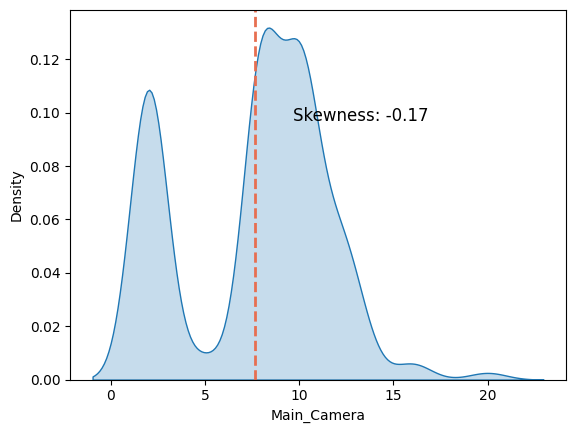

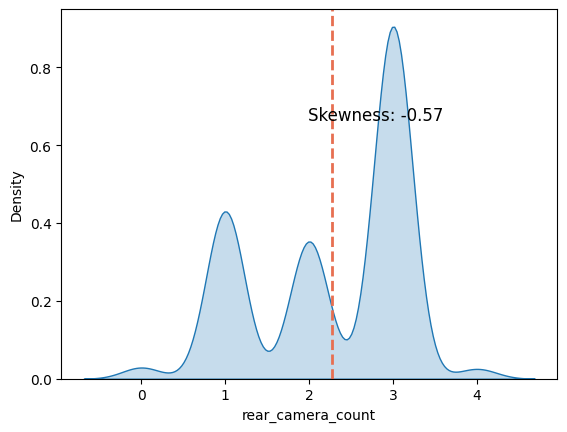

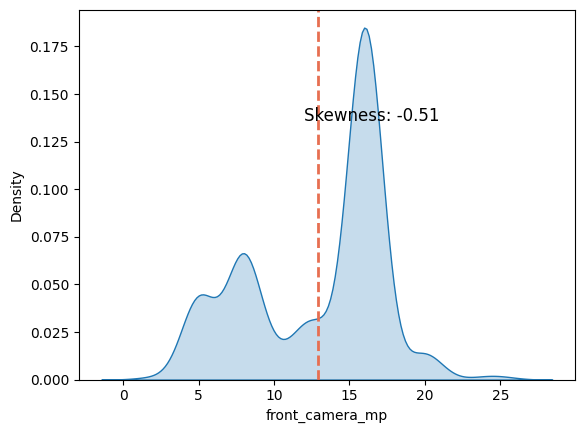

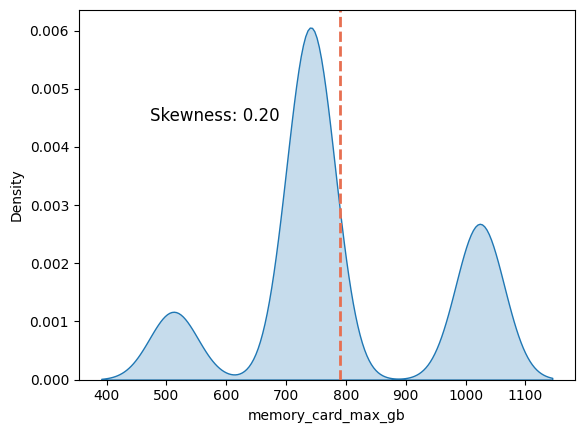

In [81]:
for col in df.select_dtypes(include=['number']).columns:
    sns.kdeplot(df[col], fill=True)
    plt.axvline(df[col].mean(), color='#e76f51', linestyle='--', linewidth=2)
    plt.text(plt.xlim()[1]*0.4, plt.ylim()[1]*0.7, f'Skewness: {df[col].skew():.2f}', color='black', fontsize=12)
    plt.show()

<Axes: >

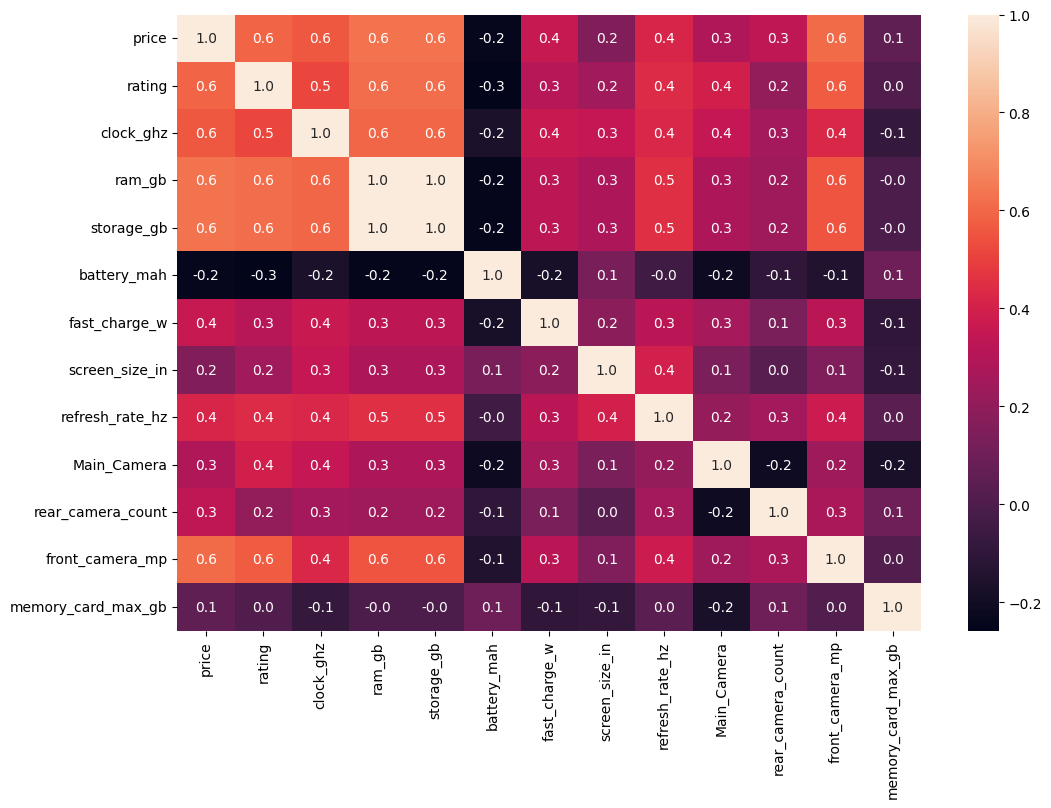

In [82]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True,fmt='.1f')

In [83]:
df.columns

Index(['model', 'price', 'rating', 'os', 'sim_type', 'network_type', 'VoLTE',
       'NFC', 'ir_blaster', 'chipset', 'core_type', 'clock_ghz', 'ram_gb',
       'storage_gb', 'battery_mah', 'fast_charge_w', 'screen_size_in',
       'resolution', 'refresh_rate_hz', 'display_type', 'Main_Camera',
       'rear_camera_count', 'front_camera_mp', 'memory_card_type',
       'memory_card_max_gb'],
      dtype='object')

In [84]:
le = LabelEncoder()
cols=['model', 'price', 'rating', 'os', 'sim_type', 'network_type', 'VoLTE',
       'NFC', 'ir_blaster', 'chipset', 'core_type', 'clock_ghz', 'ram_gb',
       'storage_gb', 'battery_mah', 'fast_charge_w', 'screen_size_in',
       'resolution', 'refresh_rate_hz', 'display_type', 'Main_Camera',
       'rear_camera_count', 'front_camera_mp', 'memory_card_type',
       'memory_card_max_gb']
for col in cols:
    df[col] = le.fit_transform(df[col])
print(df)

     model  price  rating  os  sim_type  network_type  VoLTE  NFC  ir_blaster  \
0      232    157      27   8         0             1      1    1           0   
1      252    155      19   6         0             1      1    0           0   
2      452    132      13   8         0             1      1    0           0   
3      192    122      19   6         0             1      1    0           0   
4      376    194      20   8         0             1      1    0           0   
..     ...    ...     ...  ..       ...           ...    ...  ...         ...   
963    176    157      21   6         0             1      1    0           0   
964     64    121      13   4         0             1      1    0           0   
965    368    219      23   6         0             1      1    1           1   
966    199    156      18   6         0             1      1    1           0   
967    501    192      12   6         0             1      1    0           0   

     chipset  ...  fast_cha

In [103]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df["Feature"] = df.columns
vif_df["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
vif_df = vif_df.sort_values(by="VIF", ascending=False)

print(vif_df)

               Feature       VIF
7          battery_mah  8.724103
9       screen_size_in  8.382754
13   rear_camera_count  7.972394
0                model  4.981315
8        fast_charge_w  4.789615
3         network_type  4.270017
6              chipset  4.165625
15  memory_card_max_gb  3.683739
12         Main_Camera  3.582048
1                   os  3.154513
4                  NFC  2.884072
10          resolution  2.682217
11     refresh_rate_hz  2.434655
5           ir_blaster  1.689575
14    memory_card_type  1.376968
2             sim_type  1.056427


In [102]:
df=df.drop(columns=['front_camera_mp'])

In [104]:
# Define X, y
y = df['sim_type']
X = df.drop(columns=['sim_type'])

In [105]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [106]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [107]:
# 5. Standard Scaler (Z-score) features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[0.29896907, 0.23529412, 1.        , ..., 0.75      , 0.        ,
        0.33333333],
       [0.32474227, 0.17647059, 1.        , ..., 0.75      , 1.        ,
        1.        ],
       [0.58247423, 0.23529412, 1.        , ..., 0.75      , 0.        ,
        1.        ],
       ...,
       [0.4742268 , 0.17647059, 1.        , ..., 0.75      , 0.        ,
        0.33333333],
       [0.2564433 , 0.17647059, 1.        , ..., 0.75      , 0.        ,
        1.        ],
       [0.64561856, 0.17647059, 1.        , ..., 0.75      , 0.        ,
        1.        ]])

In [108]:
X_train.shape

(677, 15)

In [109]:
X_test.shape

(291, 15)

In [110]:
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [111]:
# Baseline logistic regression model
logreg = LogisticRegression(random_state=42,  class_weight='balanced',max_iter=1000)
logreg.fit(X_train, y_train)

# Make predictions
y_pred = logreg.predict(X_test)
y_pred

D:\Imarticus\Anaconda\envs\Deep_Learning\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0])

In [112]:
y_pred_proba = logreg.predict_proba(X_test)[:,1]
y_pred_proba

array([3.02373844e-02, 1.53339549e-02, 5.20861827e-03, 1.86658680e-03,
       5.56767084e-02, 2.50950303e-06, 1.79870185e-01, 1.60000466e-01,
       5.84853652e-03, 4.75311214e-05, 1.92524810e-02, 1.91733956e-01,
       7.63565464e-01, 9.40449774e-04, 3.40194319e-03, 6.49796416e-01,
       1.90572666e-03, 1.44134471e-05, 4.83364908e-01, 4.64511721e-01,
       6.11471202e-01, 4.87431886e-02, 6.13297152e-01, 2.05469974e-01,
       2.04346430e-02, 5.54576097e-06, 3.03671140e-04, 3.34707762e-03,
       4.36079827e-03, 1.54919285e-02, 3.19183618e-01, 8.94880055e-01,
       8.17316256e-04, 1.41149989e-02, 6.10868819e-05, 5.81539540e-02,
       7.95096470e-01, 9.59759027e-01, 3.19191181e-03, 6.81965145e-01,
       6.65264537e-03, 9.38005110e-02, 1.17231759e-01, 5.25196755e-01,
       9.76922925e-04, 7.80157368e-01, 1.99075415e-02, 5.91776241e-04,
       2.93093096e-02, 7.00728425e-03, 4.24819274e-03, 7.45220534e-02,
       8.85879129e-01, 6.32580276e-02, 1.31494784e-01, 9.64452166e-04,
      

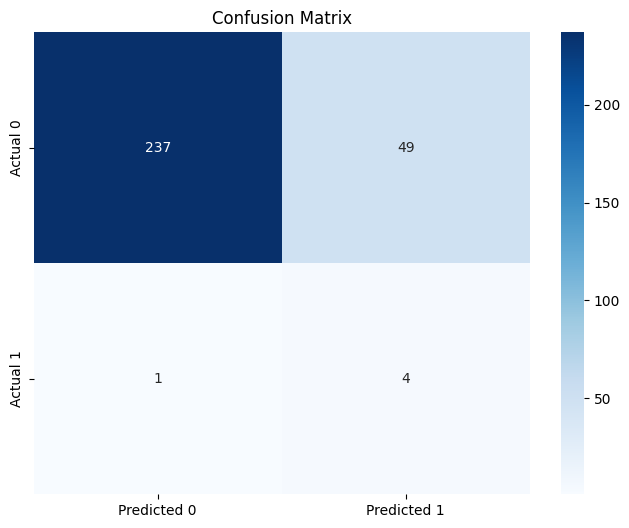

In [113]:
# 10.3 Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

plt.title('Confusion Matrix')
plt.show()

## check model

In [114]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.83      0.90       286
           1       0.08      0.80      0.14         5

    accuracy                           0.83       291
   macro avg       0.54      0.81      0.52       291
weighted avg       0.98      0.83      0.89       291



In [115]:
auc = roc_auc_score(y_test, y_pred_proba)

print("AUC:", auc)

AUC: 0.9195804195804196


In [116]:
train_acc = logreg.score(X_train, y_train)
test_acc  = logreg.score(X_test, y_test)

print("Train accuracy:", train_acc)
print("Test accuracy :", test_acc)

Train accuracy: 0.827178729689808
Test accuracy : 0.8281786941580757


sim_type
0    952
1     16
Name: count, dtype: int64

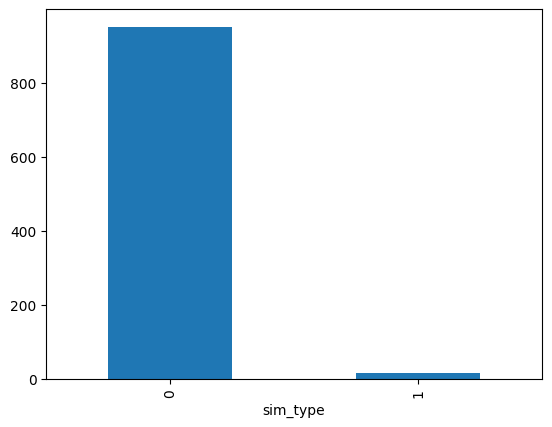

In [117]:
y.value_counts().plot(kind='bar')
y.value_counts()

In [118]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42,sampling_strategy=1)
X_resampled, y_resampled = smote.fit_resample(X, y)

D:\Imarticus\Anaconda\envs\Deep_Learning\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


sim_type
0    952
1    952
Name: count, dtype: int64

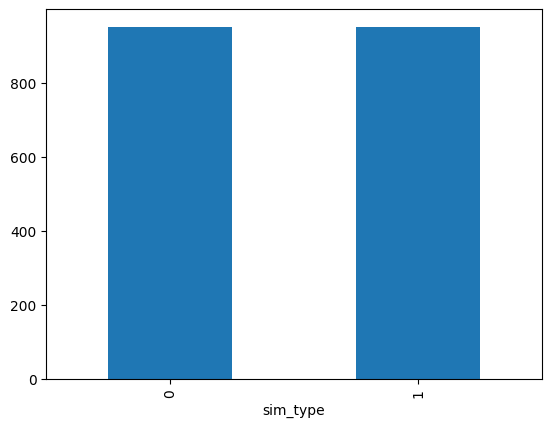

In [119]:
y_resampled.value_counts().plot(kind='bar')
y_resampled.value_counts()